In [15]:
#XGboost là một thuật toán máy học hiện đại dựa trên Gradient boost và decision tree, là một trong những thuật toán máy học tốt nhất hiện nay
import pandas as pd
import xgboost as xgb
import optuna
import joblib
import time
from datetime import datetime
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# --- 1. LOAD YOUR PRE-SCALED FILES ---
# Replace with your actual filenames
train_df = pd.read_csv("sonar_train_standard.csv")
test_df = pd.read_csv("sonar_test_standard.csv")

# Assume the last column is the target 'label'
X_train = train_df.iloc[:, :-1]
y_train = train_df.iloc[:, -1]
X_test = test_df.iloc[:, :-1]
y_test = test_df.iloc[:, -1]
# Define the mapping
mapping = {'R': 0, 'M': 1}

# Apply to the last column of both dataframes
y_train = y_train.map(mapping)
y_test = y_test.map(mapping)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, 
    y_train, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train
)
def objective(trial):
    # Hyperparameter search space
    params = {
        'booster': 'gbtree',
        'max_depth': trial.suggest_int('max_depth', 1, 2),      # KEEP THIS LOW
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 0.5),
        'early_stopping_rounds': 50,
        'eval_metric': 'logloss',
        'random_state': 42
    }

    # Internal K-Fold using ONLY the training file
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    model = xgb.XGBClassifier(**params)
    
    # Fit using X_val for the stopping logic
    model.fit(
        X_train, y_train, 
        eval_set=[(X_val, y_val)], 
        verbose=False
    )
    # Return accuracy on the Validation set
    return accuracy_score(y_val, model.predict(X_val))

# --- 2. OPTIMIZATION ---
study = optuna.create_study(direction='maximize')
start_p = time.time()
study.optimize(objective, n_trials=100)
end_p = time.time()

# --- 3. FINAL TRAINING & SAVING ---
best_params = study.best_params
final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

# Final check on the actual Test File
y_pred = final_model.predict(X_test)
final_test_acc = accuracy_score(y_test, y_pred)

# Save best model
model_name = f"final_sonar_model_{datetime.now().strftime('%H%M')}.pkl"
joblib.dump(final_model, model_name)

# --- 4. LOGGING ---
log_text = f"""
DATE: {datetime.now().strftime('%Y-%m-%d %H:%M')}
TRAIN CV ACCURACY: {study.best_value:.4f}
FINAL TEST ACCURACY: {final_test_acc:.4f} 
BEST PARAMS: {best_params}
MODEL FILE: {model_name}
"""
print(log_text)

with open("sonar_ml_log.txt", "a") as f:
    f.write(log_text)

[I 2026-03-30 15:50:22,882] A new study created in memory with name: no-name-307b6605-2dcc-4ce4-9a45-d3510ab53cbc
[I 2026-03-30 15:50:24,718] Trial 0 finished with value: 0.8275862068965517 and parameters: {'max_depth': 1, 'learning_rate': 0.02835756498992106, 'n_estimators': 784, 'colsample_bytree': 0.36268890225193806}. Best is trial 0 with value: 0.8275862068965517.
[I 2026-03-30 15:50:25,779] Trial 1 finished with value: 0.7586206896551724 and parameters: {'max_depth': 2, 'learning_rate': 0.017538490124795546, 'n_estimators': 398, 'colsample_bytree': 0.48214265251161786}. Best is trial 0 with value: 0.8275862068965517.
[I 2026-03-30 15:50:26,046] Trial 2 finished with value: 0.7586206896551724 and parameters: {'max_depth': 1, 'learning_rate': 0.0416879525916872, 'n_estimators': 103, 'colsample_bytree': 0.4938051868819024}. Best is trial 0 with value: 0.8275862068965517.
[I 2026-03-30 15:50:27,145] Trial 3 finished with value: 0.7931034482758621 and parameters: {'max_depth': 2, 'lea


DATE: 2026-03-30 15:52
TRAIN CV ACCURACY: 0.9310
FINAL TEST ACCURACY: 0.7937 
BEST PARAMS: {'max_depth': 1, 'learning_rate': 0.017871027340047706, 'n_estimators': 690, 'colsample_bytree': 0.4976545546313268}
MODEL FILE: final_sonar_model_1552.pkl



F10: 17.0512
F51: 11.7530
F12: 10.2108
F13: 9.1001
F05: 8.4305
F45: 5.8986
F11: 4.9203
F36: 4.3314
F21: 4.1294
F04: 3.8815


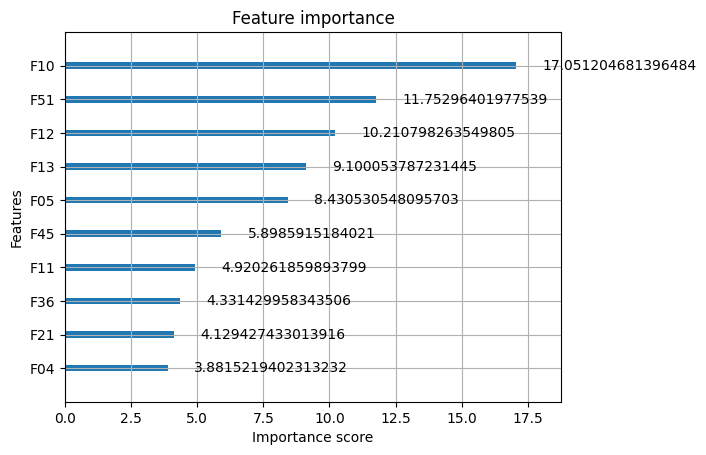

In [16]:
# tính năng đặc biệt của xgboost là khả năng lựa chọn đặc trưng và xếp hạng độ quan trọng
import joblib
import xgboost as xgb
import matplotlib.pyplot as plt

# 1. Load the "brain" back from the disk
model = joblib.load("final_sonar_model_1552.pkl") 

# 2. Extract the importance scores
# 'weight' = how many times a frequency was used to split
# 'gain' = how much that frequency improved the model's "certainty"
importance = model.get_booster().get_score(importance_type='gain')

# 3. Sort and Plot
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
for feature, score in sorted_importance[:10]:
    print(f"{feature}: {score:.4f}")

xgb.plot_importance(model, importance_type='gain', max_num_features=10)
plt.show()

In [18]:
all_features = set(X_train.columns)
used_features = set(importance.keys())
discarded_features = all_features - used_features

print(f" những đặc trưng bị bỏ qua:{len(discarded_features)}")
print(f"{discarded_features}")

 những đặc trưng bị bỏ qua:34
{'F19', 'F42', 'F25', 'F38', 'F18', 'F60', 'F07', 'F29', 'F20', 'F22', 'F17', 'F09', 'F58', 'F59', 'F06', 'F50', 'F08', 'F34', 'F30', 'F41', 'F40', 'F49', 'F02', 'F56', 'F46', 'F14', 'F47', 'F24', 'F33', 'F57', 'F35', 'F03', 'F26', 'F15'}
